# Bias–variance decomposition from scratch

This notebook rebuilds Section 8.2.2 of [Chapter 8](../chapter-08-measuring-performance.pdf) for a reader who has little prior experience with statistical bias and variance.

The destination is Equation 8.7, using the book's notation throughout:

$$
\mathbb{E}_{\mathcal D}\mathbb{E}_{y}
\left[(f[x,\phi[\mathcal D]]-y[x])^2\right]
=
\underbrace{\mathbb{E}_{\mathcal D}
\left[(f[x,\phi[\mathcal D]]-f_{\mu}[x])^2\right]}_{\text{model variance}}
+
\underbrace{(f_{\mu}[x]-\mu[x])^2}_{\text{squared bias}}
+
\underbrace{\sigma^2}_{\text{noise}}.
$$

We will not start there. We will first define every source of randomness, draw the repeated-experiment picture, and derive each term using ordinary algebra and real numbers.


## Topic 0 — The repeated-experiment picture


### 0.1 Hold one input $x$ fixed

The derivation is performed at one input position $x$ at a time.

Imagine $x$ describes a particular house. Even for houses with exactly these recorded features, the observed sale price $y$ may vary because the features do not capture everything: condition, negotiation, renovations, timing, and measurement error can differ.

Therefore, at this fixed $x$, there is not necessarily one inevitable target. There is a distribution

$$
\Pr(y\mid x)
$$

over possible observed targets.


### 0.2 Two separate things are random

The derivation averages over two different repeated experiments.

| Random object | Thought experiment | Expectation symbol |
|---|---|---|
| Fresh target $y$ | Keep $x$ and the fitted model fixed; repeatedly observe a new target | $\mathbb E_y$ |
| Training dataset $\mathcal D$ | Draw a new training set and retrain the model from scratch | $\mathbb E_{\mathcal D}$ |

These are different sources of variability:

- changing $y$ reveals **irreducible data noise**;
- changing $\mathcal D$ reveals **model variance**.

Most confusion in Equation 8.7 comes from mixing these two experiments.


### 0.3 Beginner symbol map

| Symbol | Meaning while $x$ is fixed |
|---|---|
| $y[x]$ | One target we might observe at input position $x$ |
| $\mu[x]$ | Mean of all possible targets at $x$ |
| $\sigma^2$ | Variance of targets around $\mu[x]$; the book assumes it is constant |
| $\mathcal D$ | One randomly sampled training dataset |
| $\phi[\mathcal D]$ | Parameters learned from training dataset $\mathcal D$ |
| $f[x,\phi[\mathcal D]]$ | Prediction at $x$ from the model trained on $\mathcal D$ |
| $f_{\mu}[x]$ | Expected model output over all possible training datasets |
| $\mathbb E_y$ | Average over possible fresh targets |
| $\mathbb E_{\mathcal D}$ | Average over possible training datasets |


### 0.4 The symbol $\mathbb E$ means an average

The symbol

$$
\mathbb E
$$

is read **“the expectation”** or **“the expected value.”** In this chapter, it means a probability-weighted average over a thought experiment that could be repeated many times.

For example, suppose that at one fixed input $x$, the possible targets are:

| Possible target $y[x]$ | Probability |
|---:|---:|
| $8$ | $0.25$ |
| $10$ | $0.50$ |
| $12$ | $0.25$ |

Then

$$
\begin{aligned}
\mathbb E_y[y[x]]
&=0.25(8)+0.50(10)+0.25(12)\\
&=2+5+3\\
&=10.
\end{aligned}
$$

So $\mathbb E_y[y[x]]=10$ means that the probability-weighted average target at this $x$ is $10$. It does not mean every observation equals $10$.


### 0.5 Distinguish one random output from a vector of possible values

In this one-dimensional regression problem, $y[x]$ is a **scalar random output** at the fixed input $x$.

Before we observe it, we do not know which scalar value will occur. One draw might produce $8$, another might produce $10$, and another might produce $12$.

The book's symbol

$$
y[x]
$$

does not mean the vector $[8,10,12]^T$. It means the random scalar whose possible values happen to be $8$, $10$, and $12$ in this example.

We may list those possibilities computationally as a vector:

$$
\mathbf y_x=
\begin{bmatrix}
8\\10\\12
\end{bmatrix},
$$

but $\mathbf y_x$ is our vector representation of the possible values, not the book's random-variable symbol $y[x]$.


### 0.6 Discrete expectation can be calculated as a vector dot product

List the possible values and their probabilities:

$$
\mathbf y_x=
\begin{bmatrix}
8\\10\\12
\end{bmatrix},
\qquad
\mathbf p_x=
\begin{bmatrix}
0.25\\0.50\\0.25
\end{bmatrix}.
$$

The expected target is

$$
\mathbb E_y[y[x]]
=\mathbf p_x^T\mathbf y_x
=0.25(8)+0.50(10)+0.25(12)
=10.
$$

This vector calculation is a convenient implementation of the weighted average. The expectation notation itself still describes an average over the scalar random output $y[x]$.


### 0.7 The function $g$ is a placeholder calculation

The expression

$$
\mathbb E_y[g(y[x])]
$$

means:

1. Draw or consider one possible scalar value of $y[x]$.
2. Apply the chosen calculation $g$ to that scalar.
3. Average the resulting values using their probabilities.

The letter $g$ has no special meaning. It stands for whatever calculation we currently care about.

For example, choose

$$
g(u)=(u-10)^2.
$$

Applied separately to the three possible targets:

$$
g(8)=4,
\qquad g(10)=0,
\qquad g(12)=4.
$$

Each individual evaluation returns one scalar. If we apply $g$ elementwise to our vector of listed possibilities, we obtain

$$
g(\mathbf y_x)
=
\begin{bmatrix}
4\\0\\4
\end{bmatrix}.
$$

The expectation is the dot product

$$
\begin{aligned}
\mathbb E_y[g(y[x])]
&=\mathbf p_x^Tg(\mathbf y_x)\\
&=0.25(4)+0.50(0)+0.25(4)\\
&=2.
\end{aligned}
$$

Different targets can produce the same transformed value. Here, both $8$ and $12$ produce $4$, so the transformed value $4$ has total probability $0.25+0.25=0.50$.


### 0.8 Continuous expectation replaces the finite vector sum with an integral

For a continuous target, there are infinitely many possible values, so no finite vector can list all of them exactly.

At one possible target value, $g(y[x])$ is still one scalar. Its tiny weighted contribution is

$$
\underbrace{g(y[x])}_{\text{calculated scalar}}
\times
\underbrace{\Pr(y\mid x)}_{\text{density height}}
\times
\underbrace{dy}_{\text{tiny width}}.
$$

The product

$$
\Pr(y\mid x)\,dy
$$

is approximately the probability of a tiny interval near $y$. The integral adds the contributions from all such intervals:

$$
\mathbb E_y[g(y[x])]
=\int g(y[x])\Pr(y\mid x)\,dy.
$$

Thus, the discrete and continuous calculations express the same idea:

| Discrete outcomes | Continuous outcomes |
|---|---|
| List possible values in a vector | Values range continuously |
| Probability weights $p_j$ | Density weight $\Pr(y\mid x)dy$ |
| Add with $\sum_j$ or a dot product | Add continuously with $\int$ |

This equation still holds $x$ fixed. It averages vertically over possible targets at one input position; it does not yet average horizontally over different inputs.


### 0.9 The conditional expectation produces a function of $x$

Define

$$
h[x]
=\mathbb E_y[g(y[x])]
=\int g(y[x])\Pr(y\mid x)\,dy.
$$

For one fixed $x$, the integral returns one number. When $x$ changes, the conditional distribution $\Pr(y\mid x)$ may change, so the returned number may also change.

Therefore, $h[x]$ is a function:

```text
x = 1  → average over targets possible at x = 1  → h[1]
x = 2  → average over targets possible at x = 2  → h[2]
x = 3  → average over targets possible at x = 3  → h[3]
```

The book writes $\mathbb E_y$ because $x$ is understood to be fixed. A more explicit notation would be $\mathbb E_{y\mid x}$: average over the target distribution conditional on the chosen $x$.


### 0.10 A continuous example has two stages of randomness

Suppose data are generated by

$$
y[x]=2x+\epsilon,
\qquad
\epsilon\sim\mathcal N(0,1).
$$

There are two stages:

1. Draw an input $x$ from the input distribution $\Pr(x)$.
2. At that chosen $x$, draw noise $\epsilon$ and obtain one random target $y[x]$.

At $x=1$, targets are distributed around $2$. At $x=2$, they are distributed around $4$. At $x=3$, they are distributed around $6$.

If $g(u)=u$, then

$$
h[x]
=\mathbb E_y[y[x]]
=2x.
$$

Thus, averaging over random targets at each fixed input produces the conditional-mean curve $h[x]=2x$.


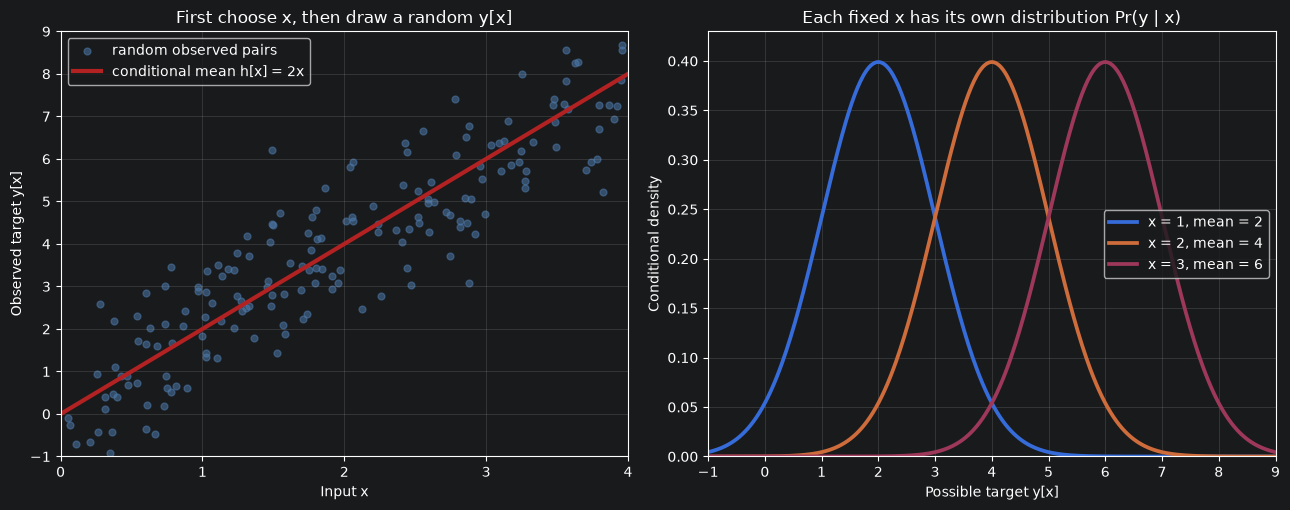

In [1]:
from typing import TypeAlias

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from numpy.typing import NDArray

FloatArray: TypeAlias = NDArray[np.float64]

rng: np.random.Generator = np.random.default_rng(8)
x_samples: np.ndarray = rng.uniform(0.0, 4.0, size=180)
y_samples: np.ndarray = 2.0 * x_samples + rng.normal(0.0, 1.0, size=x_samples.shape)
x_grid: np.ndarray = np.linspace(0.0, 4.0, 240)
y_grid: np.ndarray = np.linspace(-1.0, 9.0, 400)
selected_x: np.ndarray = np.array([1.0, 2.0, 3.0])

figure: Figure
axes: np.ndarray
figure, axes = plt.subplots(1, 2, figsize=(13, 5.2))

axes[0].scatter(x_samples, y_samples, s=24, alpha=0.55, color="#4C78A8", label="random observed pairs")
axes[0].plot(x_grid, 2.0 * x_grid, color="#B22222", linewidth=3.0, label="conditional mean h[x] = 2x")
axes[0].set(
    title="First choose x, then draw a random y[x]",
    xlabel="Input x",
    ylabel="Observed target y[x]",
    xlim=(0.0, 4.0),
    ylim=(-1.0, 9.0),
    xticks=np.arange(0.0, 4.1, 1.0),
    yticks=np.arange(-1.0, 9.1, 1.0),
)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.25)

fixed_x: np.float64
for fixed_x in selected_x:
    conditional_density: np.ndarray = np.exp(-0.5 * (y_grid - 2.0 * fixed_x) ** 2) / np.sqrt(2.0 * np.pi)
    axes[1].plot(y_grid, conditional_density, linewidth=2.7, label=f"x = {fixed_x:.0f}, mean = {2.0 * fixed_x:.0f}")

axes[1].set(
    title="Each fixed x has its own distribution Pr(y | x)",
    xlabel="Possible target y[x]",
    ylabel="Conditional density",
    xlim=(-1.0, 9.0),
    ylim=(0.0, 0.43),
    xticks=np.arange(-1.0, 9.1, 1.0),
)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.25)

figure.tight_layout()
plt.show()


### 0.11 A second expectation accounts for varying $x$

After computing the conditional result $h[x]$ at every input, average those results over the input distribution:

$$
\mathbb E_x[h[x]]
=\int h[x]\Pr(x)\,dx.
$$

Substituting the definition of $h[x]$ gives the full two-level expectation:

$$
\boxed{
\mathbb E_x\mathbb E_y[g(y[x])]
=
\int
\left[
\int g(y[x])\Pr(y\mid x)\,dy
\right]
\Pr(x)\,dx
}.
$$

Read it from the inside outward:

1. Fix one $x$ and average over its possible random targets using $\Pr(y\mid x)$.
2. Move across all possible inputs and average those conditional results using $\Pr(x)$.

For the example $h[x]=2x$, if $x$ is uniform on $[0,4]$, then $\Pr(x)=1/4$ on that interval:

$$
\begin{aligned}
\mathbb E_x\mathbb E_y[y[x]]
&=\int_0^4 2x\left(\frac14\right)\,dx\\
&=4.
\end{aligned}
$$

In practice, a representative test set approximates the outer expectation:

$$
\mathbb E_x[L[x]]
\approx
\frac{1}{N}\sum_{i=1}^{N}L[x_i].
$$


### 0.12 The chapter separates target, dataset, and input randomness

The subscript tells us which repeated experiment to average over.

At one fixed input $x$,

$$
\mathbb E_y[L[x]]
$$

averages over possible fresh targets $y[x]$ while keeping the fitted model fixed.

Also at one fixed input,

$$
\mathbb E_{\mathcal D}\mathbb E_y[L[x]]
$$

first averages over fresh targets and then averages over possible training datasets and fitted parameters $\phi[\mathcal D]$. This is the pointwise quantity decomposed in Equation 8.7.

If we want one error number for the whole input population, add the outer input expectation:

$$
\mathbb E_x\mathbb E_{\mathcal D}\mathbb E_y[L[x]].
$$

Read it from the inside outward:

1. $\mathbb E_y$: at one fixed $x$ and for one fitted model, average over possible fresh targets.
2. $\mathbb E_{\mathcal D}$: retrain on possible datasets and average the target-averaged losses.
3. $\mathbb E_x$: move across the input population and average the pointwise results.

Chapter 8 derives the decomposition at a fixed $x$ first because model variance, squared bias, and noise can each differ with the input.


## Topic 1 — Mean and noise at one input


### 1.1 Equation 8.1 defines the true conditional mean

The book writes

$$
\mu[x]
=\mathbb E_y[y[x]]
=\int y[x]\Pr(y\mid x)\,dy.
$$

Read it as:

> Average all targets that could occur at this fixed input $x$, weighting each target by how likely it is.

The integral is a continuous weighted average. It does not mean that the training set contains infinitely many repeated copies of the exact same $x$. It describes the underlying data-generating process.


### 1.2 Noise variance measures spread around the true mean

The book defines

$$
\sigma^2
=\mathbb E_y
\left[(\mu[x]-y[x])^2\right].
$$

For every possible fresh target:

1. Measure its deviation from $\mu[x]$.
2. Square that deviation.
3. Average over possible targets.

This is the variance of the observation noise. It remains even if our model knows the true mean perfectly.


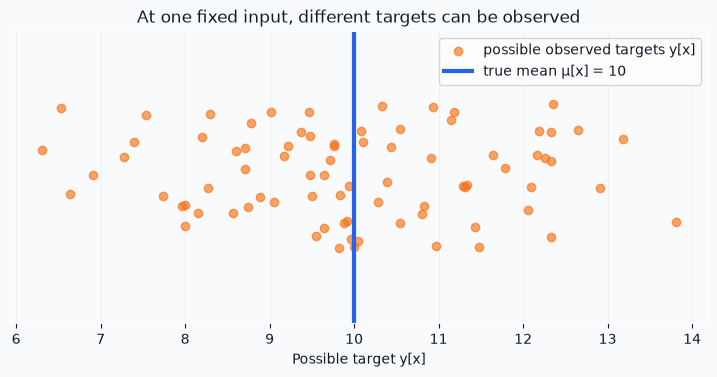

In [2]:
RANDOM_SEED: int = 8
rng: np.random.Generator = np.random.default_rng(RANDOM_SEED)
fixed_x: float = 0.25
true_mean_at_x: float = 10.0
noise_standard_deviation: float = 1.5
possible_targets: FloatArray = rng.normal(
    true_mean_at_x, noise_standard_deviation, size=80
)

noise_figure: Figure
noise_axis: Axes
noise_figure, noise_axis = plt.subplots(figsize=(9, 3.8), facecolor="#f8fafc")
noise_axis.set_facecolor("#f8fafc")
vertical_jitter: FloatArray = rng.uniform(-0.08, 0.08, size=len(possible_targets))
noise_axis.scatter(possible_targets, vertical_jitter, color="#f97316", alpha=0.65,
                   label="possible observed targets y[x]")
noise_axis.axvline(true_mean_at_x, color="#2563eb", linewidth=3,
                   label="true mean μ[x] = 10")
noise_axis.set(title="At one fixed input, different targets can be observed",
               xlabel="Possible target y[x]", yticks=[], ylim=(-0.16, 0.16))
noise_axis.tick_params(colors="#111827"); noise_axis.title.set_color("#111827")
noise_axis.xaxis.label.set_color("#111827")
noise_axis.legend(facecolor="white", labelcolor="#111827"); noise_axis.grid(axis="x", alpha=0.2)
plt.show()


## Topic 2 — Different training sets produce different models


### 2.1 The fitted model depends on dataset $\mathcal D$

A training dataset is one random sample from the data-generating process. If we draw a different dataset, its inputs and noise values differ. Training on it generally produces different parameters and a different fitted function.

We write

$$
f[x,\phi[\mathcal D]]
$$

for the prediction made at $x$ by the model trained on dataset $\mathcal D$.

This is not the heteroscedastic variance output from Chapter 5. It is variability observed when we repeatedly train separate models on separate datasets.


### 2.2 Equation 8.4 defines the expected model output

Imagine repeating the entire process many times:

1. Draw a training dataset $\mathcal D$.
2. Fit model parameters $\phi[\mathcal D]$.
3. Record the prediction $f[x,\phi[\mathcal D]]$ at the same $x$.
4. Average those predictions.

The book denotes the resulting expected model output as

$$
f_{\mu}[x]
=\mathbb E_{\mathcal D}
\left[f[x,\phi[\mathcal D]]\right].
$$


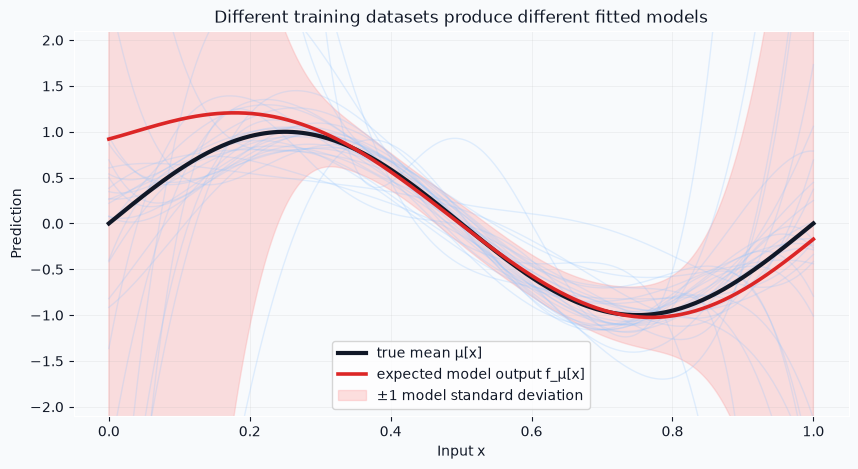

In [3]:
def true_function(x_values: FloatArray) -> FloatArray:
    return np.sin(2 * np.pi * x_values)


number_of_datasets: int = 100
training_examples_per_dataset: int = 12
polynomial_degree: int = 5
data_noise_standard_deviation: float = 0.25
x_grid: FloatArray = np.linspace(0.0, 1.0, 300)
true_mean_curve: FloatArray = true_function(x_grid)
model_predictions: list[FloatArray] = []

for dataset_index in range(number_of_datasets):
    dataset_x: FloatArray = np.sort(rng.uniform(0.0, 1.0, training_examples_per_dataset))
    dataset_y: FloatArray = (
        true_function(dataset_x)
        + rng.normal(0.0, data_noise_standard_deviation, training_examples_per_dataset)
    )
    polynomial_coefficients: FloatArray = np.polyfit(
        dataset_x, dataset_y, deg=polynomial_degree
    )
    fitted_curve: FloatArray = np.polyval(polynomial_coefficients, x_grid)
    model_predictions.append(fitted_curve)

prediction_matrix: FloatArray = np.stack(model_predictions)
average_model_curve: FloatArray = prediction_matrix.mean(axis=0)
model_standard_deviation_curve: FloatArray = prediction_matrix.std(axis=0)

fits_figure: Figure
fits_axis: Axes
fits_figure, fits_axis = plt.subplots(figsize=(10, 5), facecolor="#f8fafc")
fits_axis.set_facecolor("#f8fafc")
for fitted_curve in prediction_matrix[:30]:
    fits_axis.plot(x_grid, fitted_curve, color="#93c5fd", alpha=0.25, linewidth=1)
fits_axis.plot(x_grid, true_mean_curve, color="#111827", linewidth=3,
               label="true mean μ[x]")
fits_axis.plot(x_grid, average_model_curve, color="#dc2626", linewidth=2.6,
               label="expected model output f_μ[x]")
fits_axis.fill_between(
    x_grid,
    average_model_curve - model_standard_deviation_curve,
    average_model_curve + model_standard_deviation_curve,
    color="#fca5a5",
    alpha=0.35,
    label="±1 model standard deviation",
)
fits_axis.set(title="Different training datasets produce different fitted models",
              xlabel="Input x", ylabel="Prediction")
fits_axis.set_ylim(-2.1, 2.1)
fits_axis.tick_params(colors="#111827"); fits_axis.title.set_color("#111827")
fits_axis.xaxis.label.set_color("#111827"); fits_axis.yaxis.label.set_color("#111827")
fits_axis.legend(facecolor="white", labelcolor="#111827"); fits_axis.grid(alpha=0.2)
plt.show()


### 2.3 The word variance is used for two different objects

| Name | What varies? | Formula at fixed $x$ |
|---|---|---|
| Noise variance | Fresh observed target $y[x]$ | $\mathbb E_y[(y[x]-\mu[x])^2]$ |
| Model variance | Fitted model as $\mathcal D$ changes | $\mathbb E_{\mathcal D}[(f[x,\phi[\mathcal D]]-f_{\mu}[x])^2]$ |

Both are variances because both average squared deviations from a mean. But they describe different repeated experiments.


## Topic 3 — First decomposition: prediction error plus noise


### 3.1 Start with one model and one observed target

For now, keep the training dataset and fitted model fixed. At input $x$, squared error is

$$
L[x]=(f[x,\phi[\mathcal D]]-y[x])^2.
$$

This error mixes together:

- the model's error relative to the true mean;
- the random deviation of this particular target from the true mean.

Equation 8.2 separates them.


### 3.2 Why add and subtract $\mu[x]$?

Use the identity

$$
a-c=(a-b)+(b-c).
$$

Set

$$
a=f[x,\phi[\mathcal D]],
\qquad b=\mu[x],
\qquad c=y[x].
$$

Then

$$
f[x,\phi[\mathcal D]]-y[x]
=
\underbrace{f[x,\phi[\mathcal D]]-\mu[x]}_{\text{model-to-mean error}}
+
\underbrace{\mu[x]-y[x]}_{\text{noise in this observation}}.
$$

We added and subtracted the same number, so the expression did not change. We merely inserted the true mean as a useful intermediate point.


### 3.3 Expand the square without skipping a step

Use

$$
(a+b)^2=a^2+2ab+b^2.
$$

Therefore,

$$
\begin{aligned}
L[x]
={}&(f[x,\phi[\mathcal D]]-\mu[x])^2 \\
&+2(f[x,\phi[\mathcal D]]-\mu[x])(\mu[x]-y[x]) \\
&+(\mu[x]-y[x])^2.
\end{aligned}
$$

The middle term is called a **cross term** because it multiplies the model-to-mean error by the observation noise.


### 3.4 Two expectation rules used by the book

While averaging over possible targets $y$, the model prediction and true mean are fixed.

**Rule 1: fixed quantities come outside the average.**

$$
\mathbb E_y[cZ]=c\mathbb E_y[Z]
$$

when $c$ does not depend on $y$.

**Rule 2: expectation distributes over addition.**

$$
\mathbb E_y[A+B+C]
=\mathbb E_y[A]+\mathbb E_y[B]+\mathbb E_y[C].
$$


### 3.5 Why the first cross term becomes zero

By definition,

$$
\mathbb E_y[y[x]]=\mu[x].
$$

Therefore,

$$
\mathbb E_y[\mu[x]-y[x]]
=\mu[x]-\mathbb E_y[y[x]]
=\mu[x]-\mu[x]
=0.
$$

The model-to-mean error is fixed while averaging over $y[x]$, so

$$
\begin{aligned}
&\mathbb E_y
\left[2(f[x,\phi[\mathcal D]]-\mu[x])(\mu[x]-y[x])\right]\\
&=2(f[x,\phi[\mathcal D]]-\mu[x])
\underbrace{\mathbb E_y[\mu[x]-y[x]]}_{0}\\
&=0.
\end{aligned}
$$

Positive and negative observation noise cancel on average.


### 3.6 Equation 8.3: expected error for one fitted model

After the cross term disappears,

$$
\mathbb E_y[L[x]]
=
(f[x,\phi[\mathcal D]]-\mu[x])^2
+
\mathbb E_y[(\mu[x]-y[x])^2].
$$

Recognize the final expectation as noise variance:

$$
\boxed{
\mathbb E_y[L[x]]
=(f[x,\phi[\mathcal D]]-\mu[x])^2+\sigma^2
}.
$$

Even a model that predicts $\mu[x]$ exactly has expected squared error $\sigma^2$ because fresh observations still contain noise.


## Topic 4 — Second decomposition: model variance plus squared bias


### 4.1 Insert the expected model output

Now allow the training dataset to vary. Start with the first term from Equation 8.3:

$$
(f[x,\phi[\mathcal D]]-\mu[x])^2.
$$

Add and subtract the expected model output $f_{\mu}[x]$:

$$
f[x,\phi[\mathcal D]]-\mu[x]
=
\underbrace{f[x,\phi[\mathcal D]]-f_{\mu}[x]}_{\text{this fit's deviation from expected fit}}
+
\underbrace{f_{\mu}[x]-\mu[x]}_{\text{expected fit's systematic error}}.
$$

The first part changes with the dataset. The second is fixed when averaging across datasets.


### 4.2 Why the dataset cross term also becomes zero

The expected model output was defined as

$$
f_{\mu}[x]
=\mathbb E_{\mathcal D}
\left[f[x,\phi[\mathcal D]]\right].
$$

Hence,

$$
\begin{aligned}
\mathbb E_{\mathcal D}
\left[f[x,\phi[\mathcal D]]-f_{\mu}[x]\right]
&=f_{\mu}[x]-f_{\mu}[x]\\
&=0.
\end{aligned}
$$

After expanding the square and averaging over datasets, the cross term therefore vanishes for the same structural reason as before: deviations from an expected value average to zero.


### 4.3 Equation 8.6 identifies variance and squared bias

The remaining terms are

$$
\mathbb E_{\mathcal D}
\left[(f[x,\phi[\mathcal D]]-\mu[x])^2\right]
=
\underbrace{\mathbb E_{\mathcal D}
\left[(f[x,\phi[\mathcal D]]-f_{\mu}[x])^2\right]}_{\text{model variance}}
+
\underbrace{(f_{\mu}[x]-\mu[x])^2}_{\text{squared bias}}.
$$

Bias itself is

$$
\operatorname{Bias}[x]=f_{\mu}[x]-\mu[x].
$$

Because the loss is squared error, Equation 8.7 contains **squared bias**. The book's diagram labels the component “bias,” but the displayed term is bias squared.


### 4.4 Equation 8.7 combines all three components

Substitute Equation 8.6 into Equation 8.3:

$$
\boxed{
\mathbb{E}_{\mathcal D}\mathbb{E}_{y}[L[x]]
=
\underbrace{\mathbb E_{\mathcal D}
\left[(f[x,\phi[\mathcal D]]-f_{\mu}[x])^2\right]}_{\text{model variance}}
+
\underbrace{(f_{\mu}[x]-\mu[x])^2}_{\text{squared bias}}
+
\underbrace{\sigma^2}_{\text{noise}}
}.
$$

In words:

$$
\text{expected test squared error}
=
\text{model instability}
+
\text{systematic model error}^2
+
\text{irreducible data noise}.
$$


## Topic 5 — Verify the equation with real numbers


### 5.1 A finite thought experiment

At one fixed input, suppose:

- possible targets $y[x]$ are $8$, $10$, and $12$ with probabilities $0.25$, $0.50$, and $0.25$;
- three equally likely training datasets produce predictions $7$, $9$, and $11$.

Then

$$
\mu[x]=0.25(8)+0.50(10)+0.25(12)=10,
$$

$$
f_{\mu}[x]=\frac{7+9+11}{3}=9.
$$

We can calculate every component and also average the squared error over all nine model–target combinations.


In [4]:
target_values: FloatArray = np.array([8.0, 10.0, 12.0])
target_probabilities: FloatArray = np.array([0.25, 0.50, 0.25])
model_predictions_at_x: FloatArray = np.array([7.0, 9.0, 11.0])
dataset_probabilities: FloatArray = np.full(3, 1 / 3)

true_mean: float = float(np.sum(target_probabilities * target_values))
average_prediction: float = float(np.sum(dataset_probabilities * model_predictions_at_x))
noise_variance: float = float(
    np.sum(target_probabilities * (target_values - true_mean) ** 2)
)
model_variance: float = float(
    np.sum(dataset_probabilities * (model_predictions_at_x - average_prediction) ** 2)
)
squared_bias: float = float((average_prediction - true_mean) ** 2)

expected_test_error: float = 0.0
for model_prediction, dataset_probability in zip(
    model_predictions_at_x, dataset_probabilities
):
    for target_value, target_probability in zip(target_values, target_probabilities):
        expected_test_error += (
            dataset_probability
            * target_probability
            * (model_prediction - target_value) ** 2
        )

decomposed_error: float = model_variance + squared_bias + noise_variance

print(f"True target mean μ:              {true_mean:.3f}")
print(f"Expected model output f_μ[x]:      {average_prediction:.3f}")
print(f"Model variance:                  {model_variance:.3f}")
print(f"Squared bias:                    {squared_bias:.3f}")
print(f"Noise variance:                  {noise_variance:.3f}")
print(f"Sum of three components:         {decomposed_error:.3f}")
print(f"Directly averaged squared error: {expected_test_error:.3f}")


True target mean μ:              10.000
Expected model output f_μ[x]:      9.000
Model variance:                  2.667
Squared bias:                    1.000
Noise variance:                  2.000
Sum of three components:         5.667
Directly averaged squared error: 5.667


### 5.2 Interpret the numerical result

The components are

$$
\text{model variance}=\frac{8}{3}\approx2.667,
$$

$$
\text{squared bias}=1,
$$

$$
\text{noise variance}=2.
$$

Their sum is

$$
\frac{8}{3}+1+2
=\frac{17}{3}
\approx5.667.
$$

Directly averaging every squared prediction error gives the same $5.667$. The decomposition did not approximate the error; it reorganized it exactly.


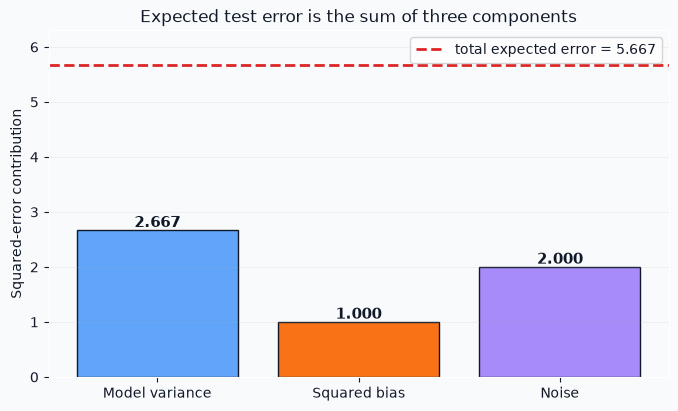

In [5]:
component_names: list[str] = ["Model variance", "Squared bias", "Noise"]
component_values: list[float] = [model_variance, squared_bias, noise_variance]
component_colors: list[str] = ["#60a5fa", "#f97316", "#a78bfa"]

bars_figure: Figure
bars_axis: Axes
bars_figure, bars_axis = plt.subplots(figsize=(8, 4.5), facecolor="#f8fafc")
bars_axis.set_facecolor("#f8fafc")
bars = bars_axis.bar(component_names, component_values, color=component_colors,
                     edgecolor="#111827")
for bar, value in zip(bars, component_values):
    bars_axis.text(bar.get_x() + bar.get_width() / 2, value + 0.06, f"{value:.3f}",
                   ha="center", color="#111827", fontweight="bold", fontsize=11)
bars_axis.axhline(expected_test_error, color="#dc2626", linestyle="--", linewidth=2,
                  label=f"total expected error = {expected_test_error:.3f}")
bars_axis.set(title="Expected test error is the sum of three components",
              ylabel="Squared-error contribution", ylim=(0, 6.3))
bars_axis.tick_params(colors="#111827"); bars_axis.title.set_color("#111827")
bars_axis.yaxis.label.set_color("#111827")
bars_axis.legend(facecolor="white", labelcolor="#111827"); bars_axis.grid(axis="y", alpha=0.2)
plt.show()


## Topic 6 — See the components across the input domain


### 6.1 Bias and model variance can change with $x$

The book derives the decomposition at one fixed $x$. We can repeat it at every position.

For the simulated polynomial models:

- model variance is large where repeated fitted curves disagree;
- squared bias is large where their average systematically misses the true curve;
- noise is constant because our simulation used homoscedastic noise.


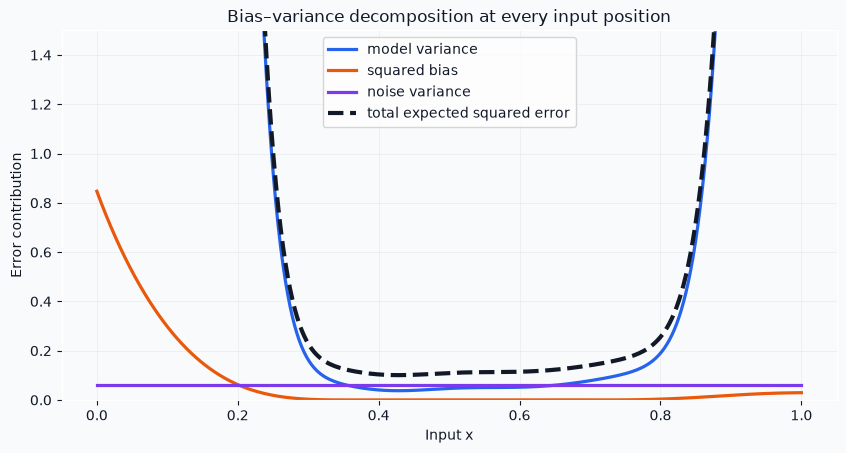

In [6]:
model_variance_curve: FloatArray = prediction_matrix.var(axis=0)
squared_bias_curve: FloatArray = (average_model_curve - true_mean_curve) ** 2
noise_curve: FloatArray = np.full_like(x_grid, data_noise_standard_deviation ** 2)
total_error_curve: FloatArray = model_variance_curve + squared_bias_curve + noise_curve

components_figure: Figure
components_axis: Axes
components_figure, components_axis = plt.subplots(figsize=(10, 4.8), facecolor="#f8fafc")
components_axis.set_facecolor("#f8fafc")
components_axis.plot(x_grid, model_variance_curve, color="#2563eb", linewidth=2.3,
                     label="model variance")
components_axis.plot(x_grid, squared_bias_curve, color="#ea580c", linewidth=2.3,
                     label="squared bias")
components_axis.plot(x_grid, noise_curve, color="#7c3aed", linewidth=2.3,
                     label="noise variance")
components_axis.plot(x_grid, total_error_curve, color="#111827", linewidth=3,
                     linestyle="--", label="total expected squared error")
components_axis.set(title="Bias–variance decomposition at every input position",
                    xlabel="Input x", ylabel="Error contribution")
components_axis.set_ylim(0, min(1.5, float(np.quantile(total_error_curve, 0.97)) * 1.2))
components_axis.tick_params(colors="#111827"); components_axis.title.set_color("#111827")
components_axis.xaxis.label.set_color("#111827"); components_axis.yaxis.label.set_color("#111827")
components_axis.legend(facecolor="white", labelcolor="#111827"); components_axis.grid(alpha=0.2)
plt.show()


## Topic 7 — Interpret the decomposition carefully


### 7.1 Bias is systematic error, not an intercept parameter

Here, **bias** does not mean the $b$ in $z=wx+b$.

Statistical bias at input $x$ is

$$
f_{\mu}[x]-\mu[x].
$$

If the expected output over many retrained models consistently predicts too high or too low, the learning procedure is biased there.


### 7.2 Model variance is sensitivity to the sampled training set

A high-variance learning procedure produces noticeably different predictions when trained on different datasets from the same population.

This is why flexible models can overfit: they may respond strongly to accidental noise in one particular training sample.

Again, this is not the same as a heteroscedastic network's predicted $\sigma^2(x)$. One is variability across retrained models; the other is a parameter of the predicted target distribution from one fitted model.


### 7.3 Noise is irreducible only relative to the available information

The $\sigma^2$ term cannot be removed by choosing a better fitted function of the current input features.

However, “irreducible” is relative to the problem definition. Better measurements or additional informative features might explain variation that currently appears to be noise.


### 7.4 Conditions behind Equation 8.7

The clean additive decomposition relies on:

- squared-error loss;
- expectations over fresh target noise and possible training datasets;
- evaluation at a fixed input $x$;
- the usual assumption that fresh test noise is independent of the sampled training dataset;
- finite means and variances.

The book assumes constant $\sigma^2$, but the same pointwise reasoning can use $\sigma^2(x)$ for heteroscedastic noise. Other losses do not necessarily produce this exact additive formula.


### 7.5 Reading checklist for Section 8.2.2

When rereading the book, translate each line using these questions:

1. What is fixed right now: $x$, the model, or the dataset?
2. What are we averaging over: fresh targets $y$ or training datasets $\mathcal D$?
3. Which quantities can therefore move outside the expectation?
4. Which deviation has mean zero by definition?
5. Is “variance” referring to target noise or retrained-model variability?

The final result is:

$$
\boxed{
\text{expected test MSE at }x
=
\text{model variance}
+
\text{squared bias}
+
\text{noise variance}
}.
$$
